# **Import Libraries**

In [85]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LeakyReLU
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# **Dataset**

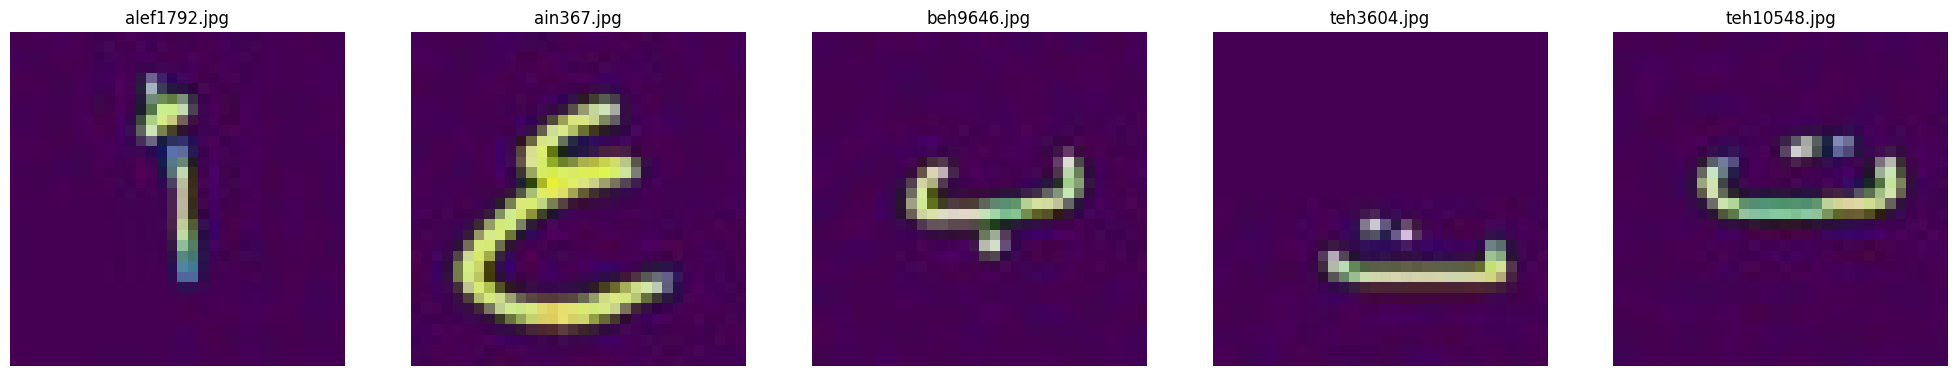

In [86]:
dataset_path = '/kaggle/input/arabic-chars-mnist/train'

image_files = os.listdir(dataset_path)[:5]  

images = [Image.open(os.path.join(dataset_path, img)) for img in image_files]

plt.figure(figsize=(25, 5)) 
for i, img in enumerate(images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')  
    plt.title(image_files[i])
plt.show()


# **Pre-processing**

In [87]:
print(os.listdir('/kaggle/input/'))

['arabic-chars-mnist']


In [88]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for filename in os.listdir(folder):
        # Load image in grayscale mode using PIL
        img_path = os.path.join(folder, filename)
        img = Image.open(img_path).convert('L')  # 'L' mode converts to grayscale

        # Convert the image to a numpy array and normalize pixel values to 0-1
        img = np.array(img) / 255.0
        images.append(img)

        # Assuming label is the first part of the filename before any non-alphabetic character
        label = ''.join(filter(str.isalpha, filename.split('.')[0]))
        labels.append(label)

    return np.array(images), labels


In [89]:
train_folder = '/kaggle/input/arabic-chars-mnist/train'
test_folder = '/kaggle/input/arabic-chars-mnist/test'   

# Load images and labels
train_images, train_labels = load_images_from_folder(train_folder)
test_images, test_labels = load_images_from_folder(test_folder)

# Reshape the images to add channel dimension
train_images = train_images.reshape(-1, 32, 32, 1)
test_images = test_images.reshape(-1, 32, 32, 1)

Train images shape: (13440, 32, 32, 1)
Train labels shape: (13440, 28)
Test images shape: (3360, 32, 32, 1)
Test labels shape: (3360, 28)


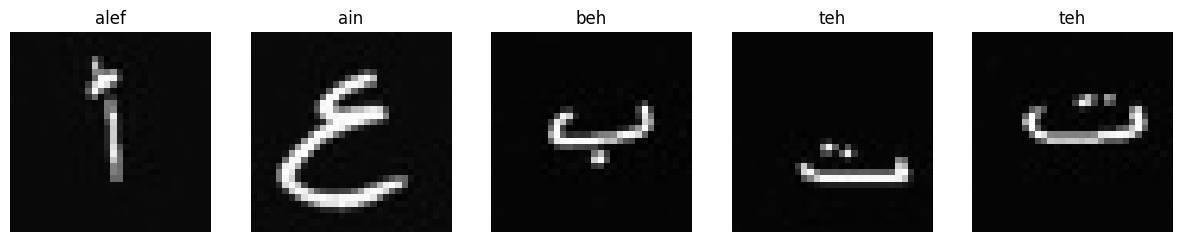

In [90]:
# Encode labels using LabelEncoder and convert to one-hot
label_encoder = LabelEncoder()
encoded_train_labels = label_encoder.fit_transform(train_labels)
encoded_test_labels = label_encoder.transform(test_labels)
train_labels_onehot = to_categorical(encoded_train_labels)
test_labels_onehot = to_categorical(encoded_test_labels)

# Check shapes to confirm everything is as expected
print('Train images shape:', train_images.shape)
print('Train labels shape:', train_labels_onehot.shape)
print('Test images shape:', test_images.shape)
print('Test labels shape:', test_labels_onehot.shape)

# Plot a few images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i].squeeze(), cmap='gray')
    ax.title.set_text(train_labels[i])
    ax.axis('off')
plt.show()

# **Buliding CNN Model**

In [91]:
# Define the CNN model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(300, activation='relu'),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')
    ])

model.summary()

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_images, train_labels_onehot, epochs=70, batch_size=64, validation_split=0.2)

#evalute the model on test dataset
test_loss, test_acc = model.evaluate(test_images, test_labels_onehot)
print("Test accuracy:", test_acc)


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 300)            │       691,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 28)             │         8,428 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 718,744 (2.74 MB)

 Trainable params: 718,744 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.1758 - loss: 2.8548 - val_accuracy: 0.5603 - val_loss: 1.4856
Epoch 2/70
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.5111 - loss: 1.5010 - val_accuracy: 0.7262 - val_loss: 0.9172
Epoch 3/70
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.6676 - loss: 0.9961 - val_accuracy: 0.7958 - val_loss: 0.6781
Epoch 4/70
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.7424 - loss: 0.7601 - val_accuracy: 0.8352 - val_loss: 0.5447
Epoch 5/70
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.7949 - loss: 0.6174 - val_accuracy: 0.8553 - val_loss: 0.4657
Epoch 6/70
168/168 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8284 - loss: 0.5132 - val_accuracy: 0.8653 - val_loss: 0.4199
Epoch 7/70
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8542 - loss: 0.4307 - val_accuracy: 0.8735 - val_loss: 0.3825
Epoch 8/70
168/168 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8645 - loss: 0.4050 - val_ac

# **Plot Training and Validation Accuracy**

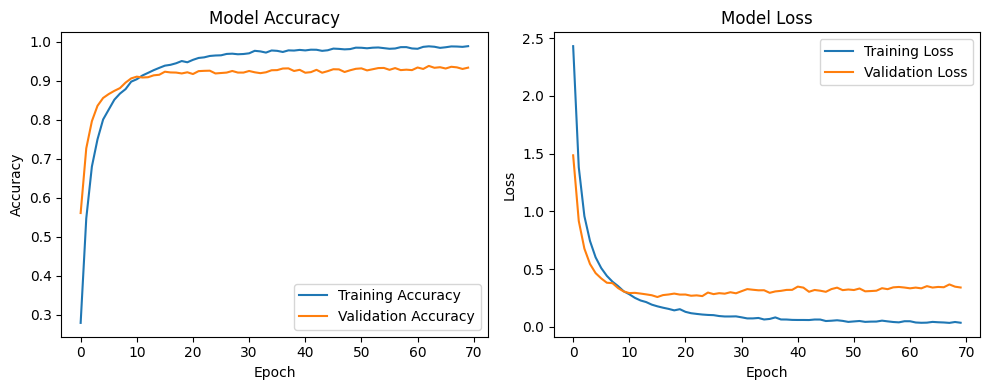

In [92]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# **Model Prediction**

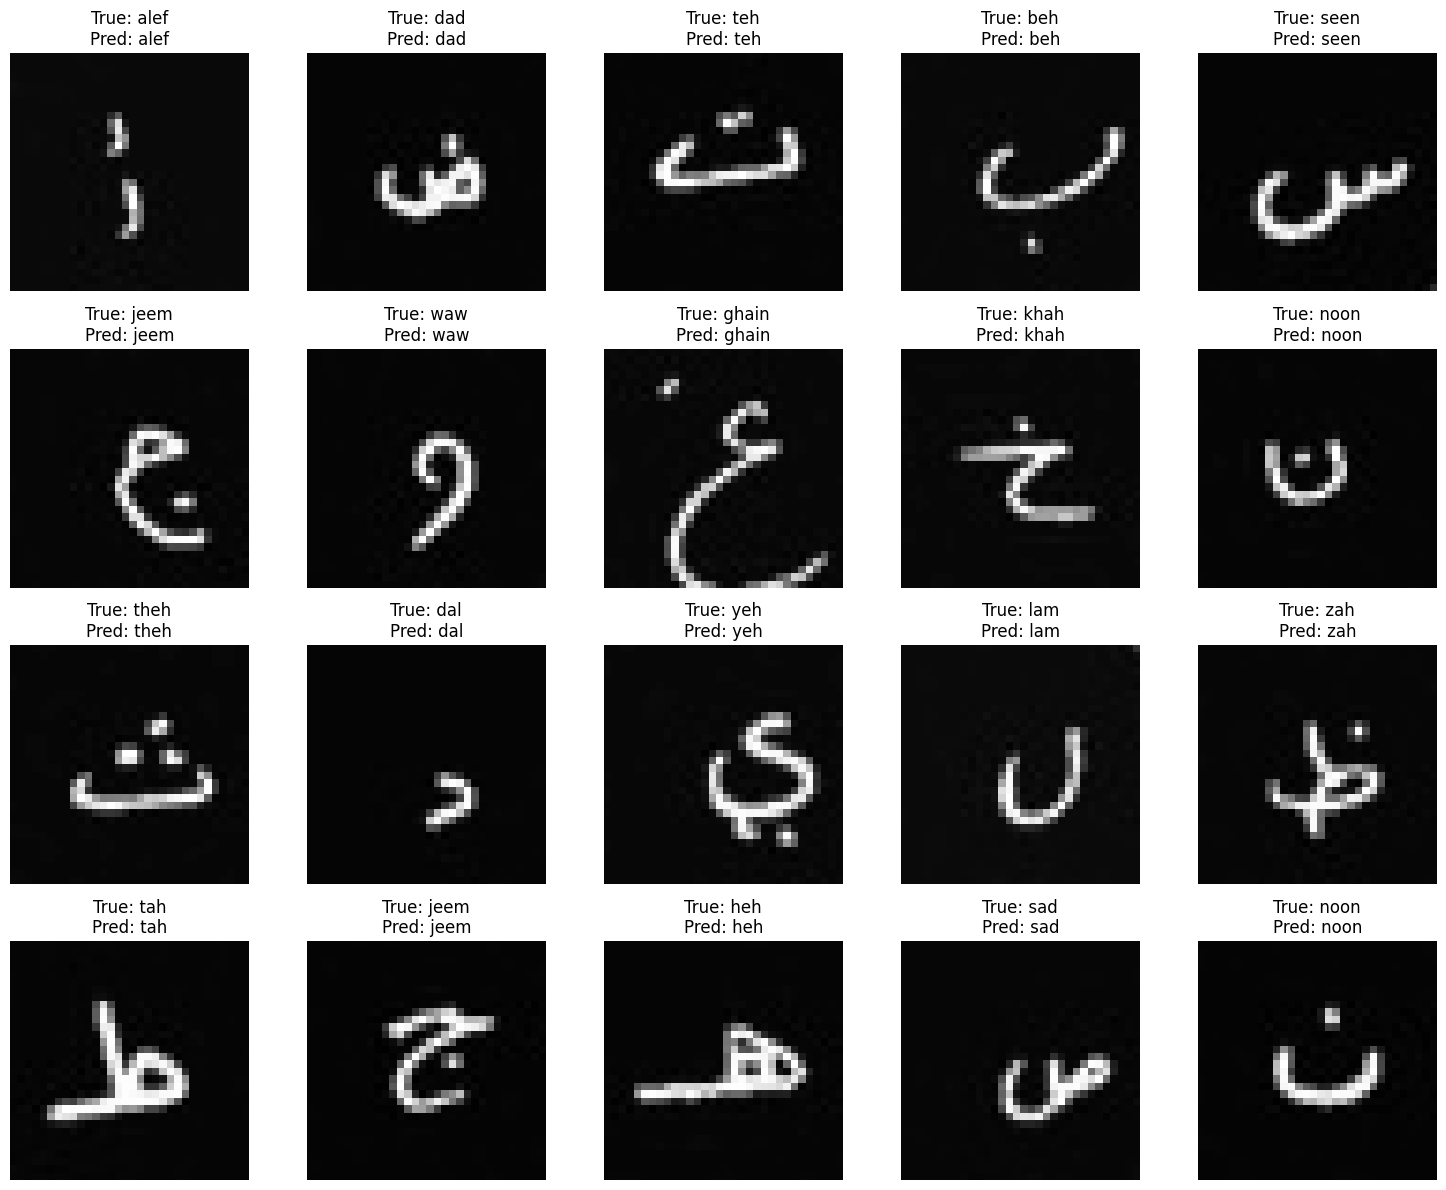

In [96]:
label_names = label_encoder.classes_

def plot_images_with_labels(images, true_classes, predicted_classes, label_names,num_images=20, per_row=5):
    num_rows = (num_images + per_row - 1) // per_row  
    plt.figure(figsize=(15, 3 * num_rows))  
    for i in range(min(num_images, len(images))):  
        plt.subplot(num_rows, per_row, i + 1)  
        plt.imshow(images[i].reshape(32, 32), cmap='gray')
        plt.title(f"True: {label_names[true_classes[i]]}\nPred: {label_names[predicted_classes[i]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_images_with_labels(test_images, true_classes, predicted_classes, label_names,num_images=20, per_row=5)

# **Evalution Metrics: Precision, Recall, F1-Score, and Confusion Matrix**

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
       precision    recall  f1-score
ain     0.918033  0.933333  0.925620
alef    1.000000  0.983333  0.991597
beh     0.959016  0.975000  0.966942
dad     0.964602  0.908333  0.935622
dal     0.940678  0.925000  0.932773
feh     0.875969  0.941667  0.907631
ghain   0.933884  0.941667  0.937759
hah     0.852941  0.966667  0.906250
heh     0.982906  0.958333  0.970464
jeem    0.956897  0.925000  0.940678
kaf     0.974138  0.941667  0.957627
khah    0.946429  0.883333  0.913793
lam     0.983471  0.991667  0.987552
meem    0.952000  0.991667  0.971429
noon    0.900826  0.908333  0.904564
qaf     0.963636  0.883333  0.921739
reh     0.900763  0.983333  0.940239
sad     0.920635  0.966667  0.943089
seen    0.966102  0.950000  0.957983
sheen   0.913386  0.966667  0.939271
tah     0.918033  0.933333  0.925620
teh     0.852713  0.916667  0.883534
thal    0.913793  0.883333  0.898305
theh    0.934579  0.833333  0.881057
waw     0.950413  0.958333  0.9543

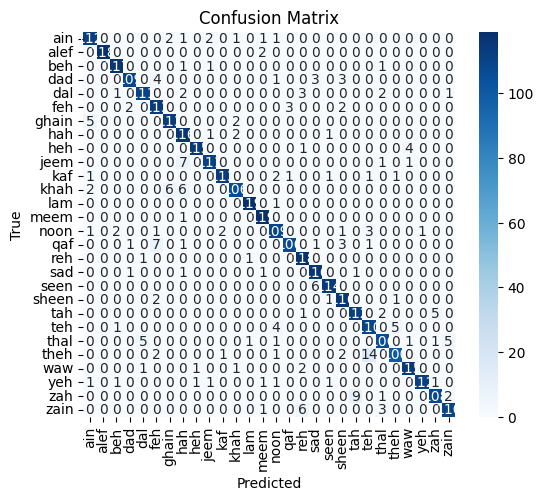

In [95]:
# Predict the labels on the test dataset
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels_onehot, axis=1)

report_dict = classification_report(true_classes, predicted_classes,target_names=label_encoder.classes_, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()

metrics_df = report_df[['precision', 'recall', 'f1-score']][:-3]  

# Print the metrics 
print(metrics_df)

# Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()